# MI of receptors activity for realistic curves.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.special import entr
import itertools

import sys
sys.path.append('../')

from src.ligand_coding_model import *
from src.receptor_information import *

# --- 1. Define General Parameters ---
Nr = 3  # Number of receptors (e.g., r0, r1, r2)

# Binning parameters
# binning parameters influence the indexing of the response.
# this is why, we define them on top
Na,Nc = 10,10
# concentration bins
c_min = 0.01
c_max = 10.0
c_edges = np.logspace(np.log10(c_min), np.log10(c_max), Nc + 1)
c_centers = np.sqrt(c_edges[:-1] * c_edges[1:])
# activity bins
a_edges = np.linspace(0, 1, Na + 1)
a_centers = 0.5*(a_edges[1:] + a_edges[:-1])
a_centers[0] = 0.
a_centers[-1] = 1.


### 1. Generate, and binning of activity curves
#### 1.1 Homo and Hetero pentamers:

In [3]:
def plot_binning_comparison(epsilon, Kos, Kcs, Nc, c_min, c_max, Na,figaxs = None,label=None,color='b'):
    """
    Generates a two-panel plot to illustrate the binning of the
    continuous Popen curve into a discrete activation curve.

    Left Panel: Smooth Popen curve with binning grid.
    Right Panel: Discretized step-plot of the activation curve.
    """
    
    # --- Get Binning Info ---
    c_edges = np.logspace(np.log10(c_min), np.log10(c_max), Nc + 1)
    c_centers = np.sqrt(c_edges[:-1] * c_edges[1:])
    c_labels = [f'$c_{{{i}}}$' for i in range(Nc)]
    
    a_edges = np.linspace(0, 1, Na + 1)
    a_values = np.arange(Na)
    
    # --- plot instances ---
    if figaxs is None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.5), sharey=True)
    else:
        fig,(ax1,ax2) = figaxs
    grid_style = {'color': 'gray', 'linestyle': ':', 'linewidth': .5, 'alpha': 0.7}

    # --- Generate Plot Data ---
    
    # 1. Smooth curve data (for left panel)
    x_plot = np.logspace(np.log10(c_min), np.log10(c_max), 500)
    #y_plot = PopenNorm(x_plot, epsilon, Ko, Kc)
    y_plot = PoHeteroNorm(x_plot, epsilon, Kos, Kcs)

    if label is None:
        ax1.plot(x_plot, y_plot, label=f'P(c, $\\epsilon={epsilon}, K_o={Ko}, K_c={Kc}$)')
    else:
        ax1.plot(x_plot, y_plot, label=label,color=color)
    ax1.set_xscale('log')

    # Add binning grid
    for t in c_edges:
        ax1.axvline(x=t, **grid_style)
    for t in a_edges[1:-1]:
        ax1.axhline(y=t, **grid_style)

    # Aesthetics
    ax1.set_xlabel('Concentration $c$')
    ax1.set_ylabel(r'$p_\text{o}(c)$')
    if c_centers.__len__()<=10:
        ax1.set_xticks(c_centers, c_labels)
    else:
        denom = c_centers.__len__()//10
        ax1.set_xticks(c_centers[0::denom], c_labels[0::denom])
    ax1.xaxis.minorticks_off()
    #ax1.set_yticks(a_edges[1:-1], [f'Threshold = {t:.2f}' for t in a_edges[1:-1]])
    ax1.set_ylim(-0.1, 1.1)
    ax1.set_xlim(c_min, c_max)
    ax1.legend(loc='center left', bbox_to_anchor=(-.0, 1.2))
    

    # 2. Discrete curve data (for right panel)
    x2, activity_curve = generate_discrete_curve(epsilon, Kos, Kcs, Nc, c_min, c_max, Na)
    
    # Create x and y data for the step plot
    x_step = c_edges
    y_step = np.append(activity_curve, activity_curve[-1])

    # --- Create Plots ---

    # === Plot 2: Binned Version ===
    if label is None:
        ax2.plot(x_step, y_step, label='discretized', drawstyle='steps-post')
    else: 
        ax2.plot(x_step, y_step, label='discretized: '+label, drawstyle='steps-post',color=color)
    ax2.set_xscale('log')

    # Add binning grid
    for t in c_edges:
        ax2.axvline(x=t, **grid_style)
    for t in a_edges[1:-1]:
        ax2.axhline(y=t, **grid_style)

    # Add text to show the binned values
    #for k in range(Nc):
    #    ax2.text(c_centers[k], 0.5, f'Bin $c_{{{k}}}$\n$a(c)={activity_curve[k]}$', 
    #             ha='center', va='center', fontsize=12)

    # Aesthetics
    ax2.set_xlabel('Concentration $c$')
    ax2.set_ylabel(r'$p_\text{o}(c)$')
    #ax2.set_xticks(c_centers, c_labels)
    if c_centers.__len__()<=10:
        ax2.set_xticks(c_centers, c_labels)
    else:
        denom = c_centers.__len__()//10
        ax2.set_xticks(c_centers[0::denom], c_labels[0::denom])
    ax2.xaxis.minorticks_off()
    ax2.set_xlim(c_min, c_max)
    ax2.set_ylim(-0.1, 1.1)
    ax2.legend(loc='center left', bbox_to_anchor=(-.0, 1.2))

    # --- Show Plot ---
    plt.tight_layout()

epsilon = -1.00 | Ko = [0.5, 0.5, 0.5, 0.5, 0.5] | Kcs = [10.0, 10.0, 10.0, 10.0, 10.0]
epsilon = -1.00 | Ko = [0.5, 0.5, 2.0, 2.0, 2.0] | Kcs = [10.0, 10.0, 5.0, 5.0, 5.0]
epsilon = -1.00 | Ko = [2.0, 2.0, 2.0, 2.0, 2.0] | Kcs = [5.0, 5.0, 5.0, 5.0, 5.0]


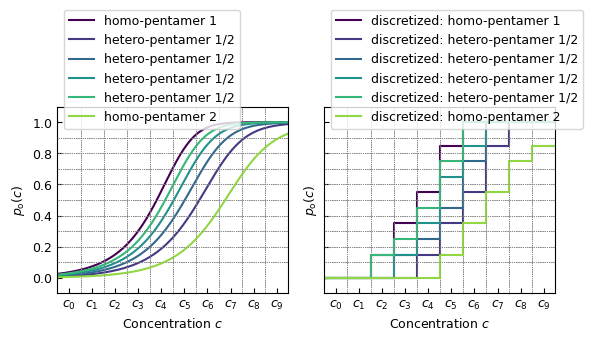

In [4]:
from matplotlib import colormaps



figaxs = plt.subplots(ncols=2,figsize=(6,3.5),sharey=True)
fig,(ax1,ax2) = figaxs

#params = np.array([[-1.0,0.5,10.],[-1.0,1.5,10.],[-1.0,2.,5.]])
params = [[-1.0,0.5,10.],[-1.0,2.,5.]]
colors = [colormaps['viridis'](i/6.) for i in range(6)]

epsilon,Kos,Kcs = params[0][0],[params[0][1]] * 5, [params[0][2]] * 5
print(f'epsilon = {epsilon:.2f} | Ko = {Kos} | Kcs = {Kcs}')

plot_binning_comparison(epsilon, Kos, Kcs, Nc, c_min, c_max, Na,figaxs=figaxs,label='homo-pentamer 1',color=colors[0])

epsilon,Kos,Kcs = params[0][0],[params[0][1]]*1 + [params[1][1]]*4, [params[0][2]]*2 + [params[1][2]]*3
plot_binning_comparison(epsilon, Kos, Kcs, Nc, c_min, c_max, Na,figaxs=figaxs,label='hetero-pentamer 1/2',color=colors[1])

epsilon,Kos,Kcs = params[0][0],[params[0][1]]*2 + [params[1][1]]*3, [params[0][2]]*2 + [params[1][2]]*3
plot_binning_comparison(epsilon, Kos, Kcs, Nc, c_min, c_max, Na,figaxs=figaxs,label='hetero-pentamer 1/2',color=colors[2])
print(f'epsilon = {epsilon:.2f} | Ko = {Kos} | Kcs = {Kcs}')

epsilon,Kos,Kcs = params[0][0],[params[0][1]]*3 + [params[1][1]]*2, [params[0][2]]*2 + [params[1][2]]*3
plot_binning_comparison(epsilon, Kos, Kcs, Nc, c_min, c_max, Na,figaxs=figaxs,label='hetero-pentamer 1/2',color=colors[3])

epsilon,Kos,Kcs = params[0][0],[params[0][1]]*4 + [params[1][1]]*1, [params[0][2]]*2 + [params[1][2]]*3
plot_binning_comparison(epsilon, Kos, Kcs, Nc, c_min, c_max, Na,figaxs=figaxs,label='hetero-pentamer 1/2',color=colors[4])

epsilon,Kos,Kcs = params[1][0],[params[1][1]] * 5, [params[1][2]] * 5
plot_binning_comparison(epsilon, Kos, Kcs, Nc, c_min, c_max, Na,figaxs=figaxs,label='homo-pentamer 2',color=colors[5])
print(f'epsilon = {epsilon:.2f} | Ko = {Kos} | Kcs = {Kcs}')
#plot_binning_comparison(epsilon, Ko, Kc, 20, c_min, c_max, 20)

#fig.savefig('hetero_homo_binning_20.svg',bbox_inches='tight')


## 

### Look at the evolution of the Mutual Information with the number of different ligands

Processing L = 2...
Processing L = 5...
Processing L = 10...
Processing L = 25...
Processing L = 50...


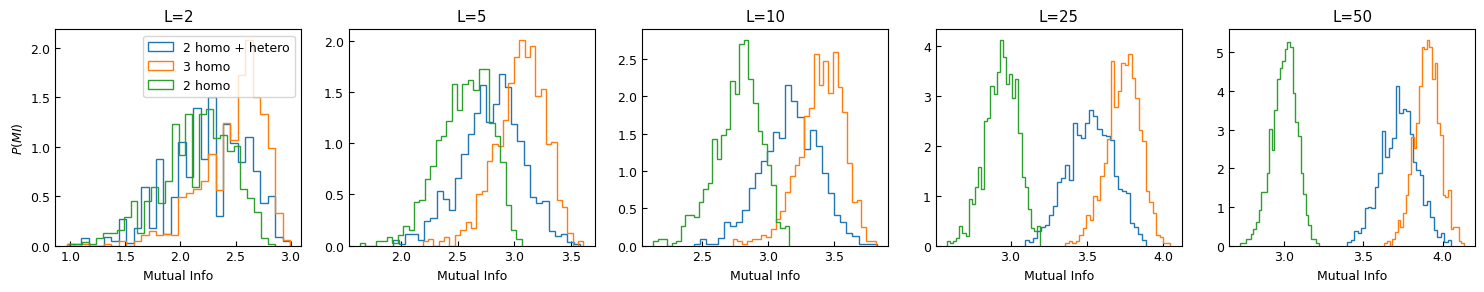

In [ ]:


# --- Main Analysis Loop ---


Nsamples = 1000
L_values = np.array([2, 5, 10, 25, 50, 100, 150, 200, 500, 1000])
L_values = np.array([2, 5, 10, 25, 50])#, 100, 150, 200, 500, 1000])

# Storage
av_MIL = np.zeros((len(L_values), 3), dtype=float)
Pas = np.zeros((len(L_values), 3, Na), dtype=float) # Stores avg P(a) for [2_homo, Hetero, 3_homo]
Pa_mat = np.zeros((len(L_values),Na,Na),dtype=float) # Store P(A) = P(a_0,a_1,a_2)

# Prepare Plot
fig, ax = plt.subplots(ncols=len(L_values), figsize=(3*len(L_values), 3))

for l_idx, L_curr in enumerate(L_values):
    print(f"Processing L = {L_curr}...")
    
    MI_3hetero, MI_3homo, MI_2 = [], [], []
    
    # Temporary accumulators for P(a)
    sum_Pa_3hetero = np.zeros(Na)
    sum_Pa_3homo   = np.zeros(Na)
    sum_Pa_2       = np.zeros(Na)

    
    for k in range(Nsamples):
        # 1. Generate Parameters
        Kcs_3hetero, Kos_3hetero, eps_3hetero = generate_Ks(L=L_curr, n_types=2, n_hetero_sample='all',Kc_Amp=50)
        Kcs_3homo,   Kos_3homo,   eps_3homo   = generate_Ks(L=L_curr, n_types=3, n_hetero_sample=0,Kc_Amp=50)
        Kcs_2,       Kos_2,       eps_2       = generate_Ks(L=L_curr, n_types=2, n_hetero_sample=0,Kc_Amp=50)
        
        # 2. Generate Activity Matrices
        A_3hetero = generate_activity_matrix(eps_3hetero, Kcs_3hetero, Kos_3hetero, c_centers, a_edges)
        A_3homo   = generate_activity_matrix(eps_3homo,   Kcs_3homo,   Kos_3homo,   c_centers, a_edges)
        A_2       = generate_activity_matrix(eps_2,       Kcs_2,       Kos_2,       c_centers, a_edges)
        
        # 3. Compute MI (Mutual Information)
        mi_hetero= compute_mi(A_3hetero)
        mi_3homo = compute_mi(A_3homo)
        mi_2     = compute_mi(A_2)
        
        MI_3hetero.append(mi_hetero)
        MI_3homo.append(mi_3homo)
        MI_2.append(mi_2)
        
        # 4. Compute and Accumulate Marginal P(a)
        sum_Pa_3hetero += compute_marginal_P(A_3hetero, Na)
        sum_Pa_3homo   += compute_marginal_P(A_3homo, Na)
        sum_Pa_2       += compute_marginal_P(A_2, Na)

        # 5 Compute and Accumulate the total activity curves P(A)
        Pa_mat[l_idx] += compute_P(A_2,Na)


    Pa_mat[l_idx] /= Nsamples
    # --- Store Averages for this L ---
    
    # Average MI
    av_MIL[l_idx] = [np.mean(MI_2), np.mean(MI_3hetero), np.mean(MI_3homo)]
    
    # Average P(a)
    Pas[l_idx, 0, :] = sum_Pa_2 / Nsamples
    Pas[l_idx, 1, :] = sum_Pa_3hetero / Nsamples
    Pas[l_idx, 2, :] = sum_Pa_3homo / Nsamples
    
    # --- Plotting Histograms (MI) ---
    ax[l_idx].hist(MI_3hetero, density=True, label='2 homo + hetero', histtype='step', bins=30)
    ax[l_idx].hist(MI_3homo,   density=True, label='3 homo',          histtype='step', bins=30)
    ax[l_idx].hist(MI_2,       density=True, label='2 homo',          histtype='step', bins=30)
    
    ax[l_idx].set_title(f'L={L_curr}')
    ax[l_idx].set_xlabel('Mutual Info')
    if l_idx == 0:
        ax[l_idx].set_ylabel(r'$P(MI)$')
        ax[l_idx].legend(loc='upper right')

plt.tight_layout()
plt.show()



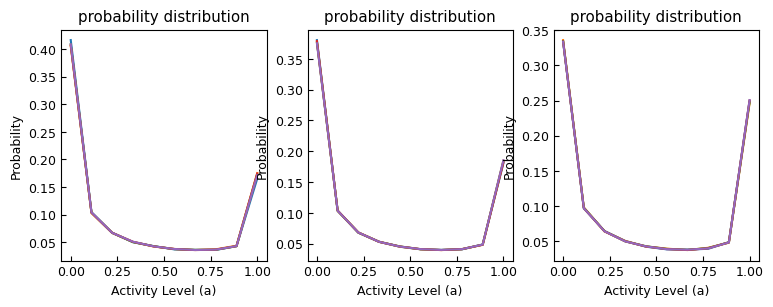

In [5]:
# --- Optional: Visualize the averaged P(a) for the largest L ---
# This shows how the activity distribution differs between the models
fig,ax = plt.subplots(ncols=(3),figsize=(9,3))
activity_levels = np.linspace(0, 1, Na) # Assuming activity centers for plotting
for l in range(Pas.shape[0]):
    ax[0].plot(activity_levels, Pas[l, 0, :], label='2 Homo')
    ax[1].plot(activity_levels, Pas[l, 1, :], label='2 Homo + Hetero')
    ax[2].plot(activity_levels, Pas[l, 2, :], label='3 Homo')

for i in range(3):
    ax[i].set_title('probability distribution')
    ax[i].set_xlabel("Activity Level (a)")
    ax[i].set_ylabel("Probability")


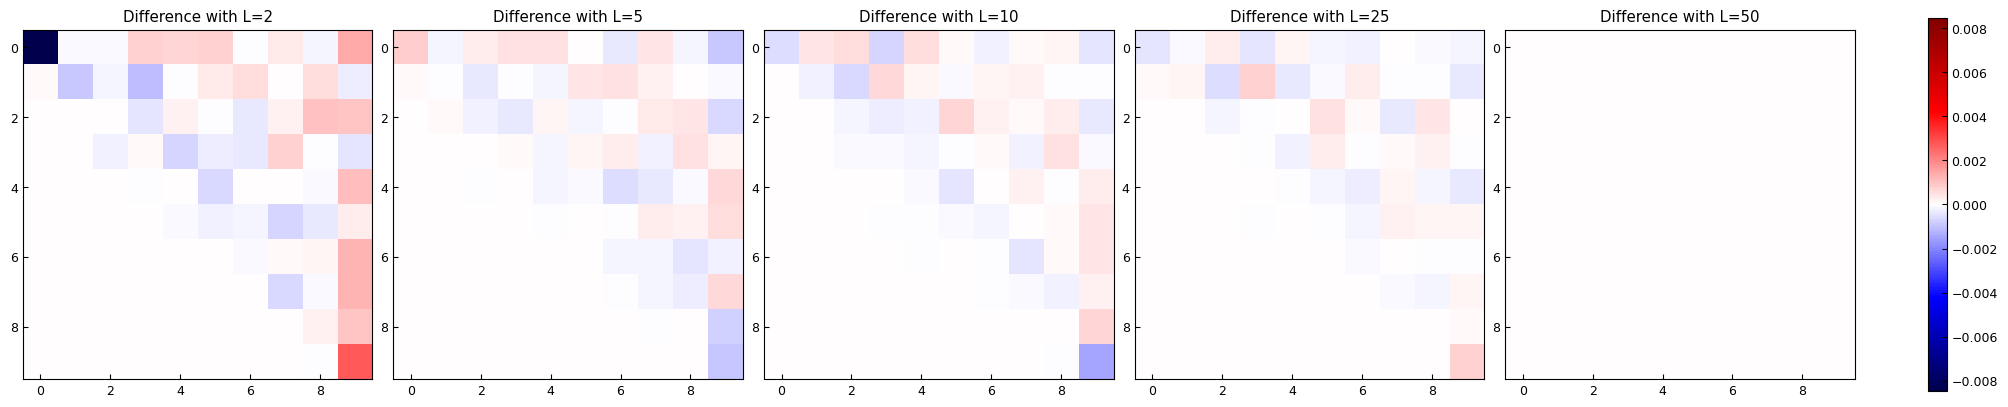

In [16]:
all_diffs = [Pa_mat[-1] - Pa_mat[l] for l in range(len(L_values))]
max_abs_val = max(np.abs(diff).max() for diff in all_diffs)

fig, ax = plt.subplots(ncols=len(L_values), figsize=(len(L_values)*4, 4), constrained_layout=True)

# Handle case where there is only 1 subplot (ax is not a list)
if len(L_values) == 1:
    ax = [ax]

for l in range(len(L_values)):
    # 2. Use vmin and vmax to lock the scale
    # 3. Use a diverging colormap (e.g., 'seismic', 'bwr', 'RdBu')
    im = ax[l].imshow(all_diffs[l], 
                      vmin=-max_abs_val, 
                      vmax=max_abs_val, 
                      cmap='seismic')
    
    ax[l].set_title(f"Difference with L={L_values[l]}")

# 4. Add a single shared colorbar for the whole figure
# We pass the image object 'im' so the colorbar knows the mapping
fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)

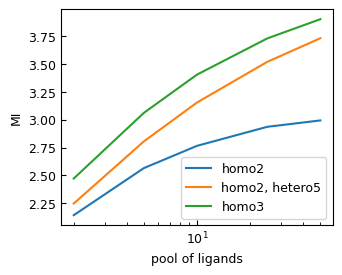

In [6]:
names = ['homo2','homo2, hetero5','homo3']
for i in range(av_MIL.shape[1]):
    plt.plot(L_values,av_MIL[:,i],label=names[i])
plt.xlabel('pool of ligands')
plt.ylabel('MI')
plt.xscale('log')
plt.legend()

# Use a different number of receptors

Processing Nr = 2...
Processing Nr = 3...
Processing Nr = 4...
Processing Nr = 5...
Processing Nr = 10...


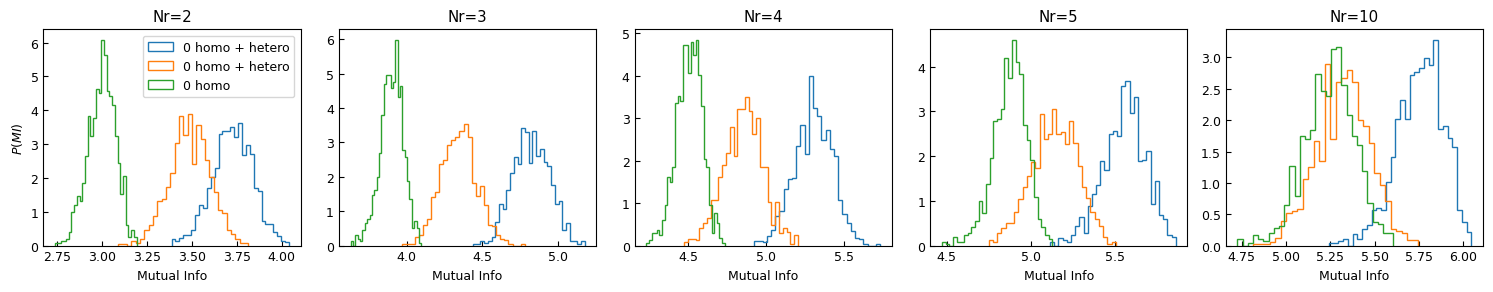

In [13]:

Nsamples = 1000
L = 1000
Nrs = [2,3,4,5,10]

# Storage
av_MIL = np.zeros((len(Nrs), 3), dtype=float)
Pas = np.zeros((len(Nrs), 3, Na), dtype=float) # Stores avg P(a) for [2_homo, Hetero, 3_homo]

# Prepare Plot
fig, ax = plt.subplots(ncols=len(Nrs), figsize=(3*len(Nrs), 3))

for nr_idx, nr in enumerate(Nrs):
    print(f"Processing Nr = {nr}...")
    
    MI_hetero_all,MI_hetero_1, MI_homo = [], [], []
    
    # Temporary accumulators for P(a)
    sum_Pa_hetero_all = np.zeros(Na)
    sum_Pa_hetero_1 = np.zeros(Na)
    sum_Pa_homo   = np.zeros(Na)
    
    for k in range(Nsamples):
        # 1. Generate Parameters
        # Note: using 'n_hetero_sample' argument from previous generalized function
        Kcs_hetero_all, Kos_hetero_all, eps_hetero_all = generate_Ks(L=L_curr, n_types=nr, n_hetero_sample='all',Kc_Amp=50.)
        Kcs_hetero_1, Kos_hetero_1, eps_hetero_1 = generate_Ks(L=L_curr, n_types=nr, n_hetero_sample=nr,Kc_Amp=50.)
        Kcs_homo,   Kos_homo,   eps_homo   = generate_Ks(L=L_curr, n_types=nr, n_hetero_sample=0,Kc_Amp=50.)
        
        # 2. Generate Activity Matrices
        A_hetero_all = generate_activity_matrix(eps_hetero_all, Kcs_hetero_all, Kos_hetero_all, c_centers, a_edges)
        A_hetero_1 = generate_activity_matrix(eps_hetero_1, Kcs_hetero_1, Kos_hetero_1, c_centers, a_edges)
        A_homo   = generate_activity_matrix(eps_homo,   Kcs_homo,   Kos_homo,   c_centers, a_edges)
        
        # 3. Compute MI (Mutual Information)
        mi_hetero_all= compute_mi(A_hetero_all, Na)
        mi_hetero_1= compute_mi(A_hetero_1, Na)
        mi_homo = compute_mi(A_homo, Na)
        
        MI_hetero_all.append(mi_hetero_all)
        MI_hetero_1.append(mi_hetero_1)
        MI_homo.append(mi_homo)
        
        # 4. Compute and Accumulate Marginal P(a)
        sum_Pa_hetero_all += compute_marginal_P(A_hetero_all, Na)
        sum_Pa_hetero_1 += compute_marginal_P(A_hetero_1, Na)
        sum_Pa_homo   += compute_marginal_P(A_homo, Na)

    # --- Store Averages for this L ---
    
    # Average MI
    av_MIL[nr_idx] = [np.mean(MI_hetero_all),np.mean(MI_hetero_1), np.mean(MI_homo)]
    
    # Average P(a)
    # Order: [Index 0: 2 homo, Index 1: Hetero, Index 2: 3 homo] (Matching av_MIL structure)
    Pas[nr_idx, 0, :] = sum_Pa_hetero_all / Nsamples
    Pas[nr_idx, 1, :] = sum_Pa_hetero_1 / Nsamples
    Pas[nr_idx, 2, :] = sum_Pa_homo / Nsamples
    
    # --- Plotting Histograms (MI) ---
    ax[nr_idx].hist(MI_hetero_all, density=True, label=str(nr_idx)+' homo + hetero', histtype='step', bins=30)
    ax[nr_idx].hist(MI_hetero_1, density=True, label=str(nr_idx)+' homo + hetero', histtype='step', bins=30)
    ax[nr_idx].hist(MI_homo,   density=True, label=str(nr_idx)+' homo',          histtype='step', bins=30)
    
    ax[nr_idx].set_title(f'Nr={nr}')
    ax[nr_idx].set_xlabel('Mutual Info')
    if nr_idx == 0:
        ax[nr_idx].set_ylabel(r'$P(MI)$')
        ax[nr_idx].legend(loc='upper right')

plt.tight_layout()
plt.show()



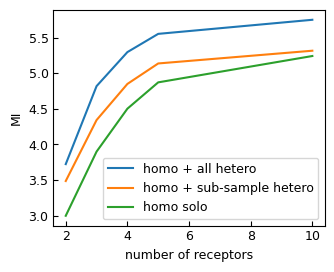

In [17]:
names = ['homo + all hetero','homo + sub-sample hetero','homo solo']
for i in range(av_MIL.shape[1]):
    plt.plot(Nrs[:],av_MIL[:,i],label=names[i])
plt.xlabel('number of receptors')
plt.ylabel('MI')
#plt.xscale('log')
plt.legend()
plt.savefig('MI_NR.svg',bbox_inches='tight')

In [ ]:
names = ['homo2','homo2, hetero5','homo3']
for i in range(av_MIL.shape[1]):
    plt.plot(Nrs[:-1],av_MIL[:-1,i],label=names[i])
plt.xlabel('pool of ligands')
plt.ylabel('MI')
#plt.xscale('log')
plt.legend()